In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
train = pd.read_csv(r"C:\Users\PRASHANTH\OneDrive\文档\Desktop\SCT_TASK_01\DATASET\train.csv")
test = pd.read_csv(r"C:\Users\PRASHANTH\OneDrive\文档\Desktop\SCT_TASK_01\DATASET\test.csv")
sample_submission = pd.read_csv(r"C:\Users\PRASHANTH\OneDrive\文档\Desktop\SCT_TASK_01\DATASET\sample_submission.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

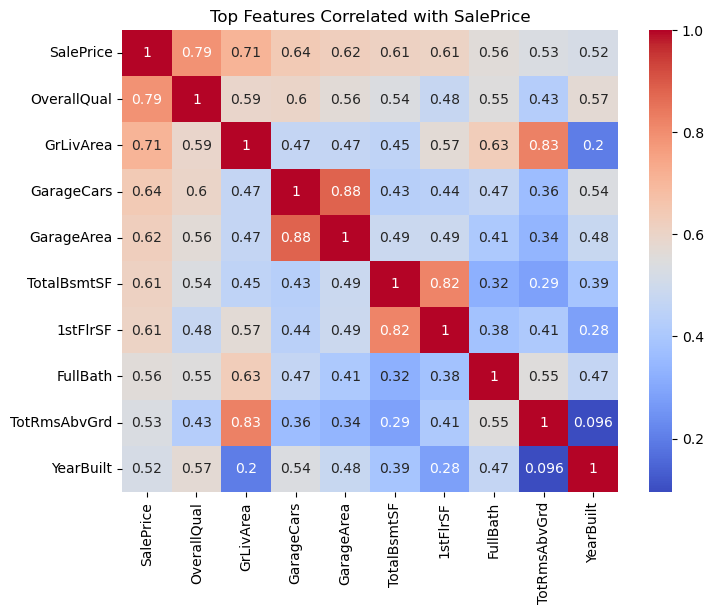

In [10]:
print(train.head())
print(train.info())
print(train.describe())

# visualize correlation
# correlation with target variable
corr_matrix = train.corr(numeric_only=True)
top_corr = corr_matrix["SalePrice"].sort_values(ascending=False)
print(top_corr.head(10))
# select top 10 correlated features
top_features = top_corr.head(10).index
corr_subset = train[top_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm")
plt.title("Top Features Correlated with SalePrice")
plt.show()


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
features = ['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','FullBath']
X = train[features]
y = train['SalePrice']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1604098912.9199414
R2 Score: 0.7908695315439265


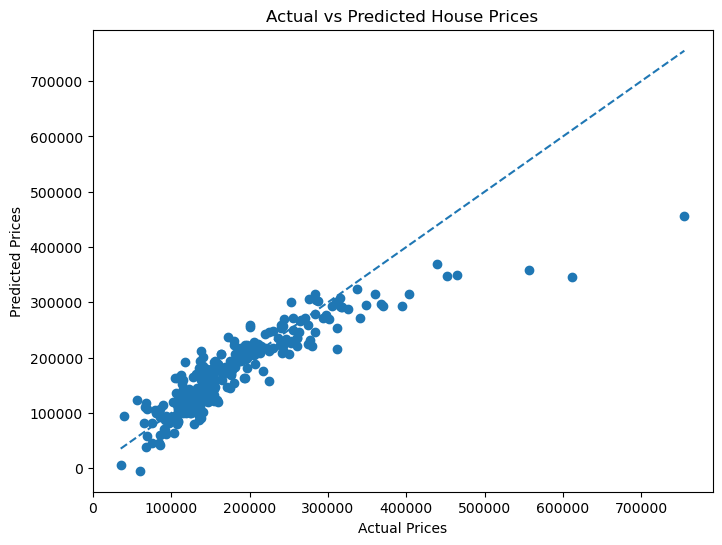

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_val, y_pred)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

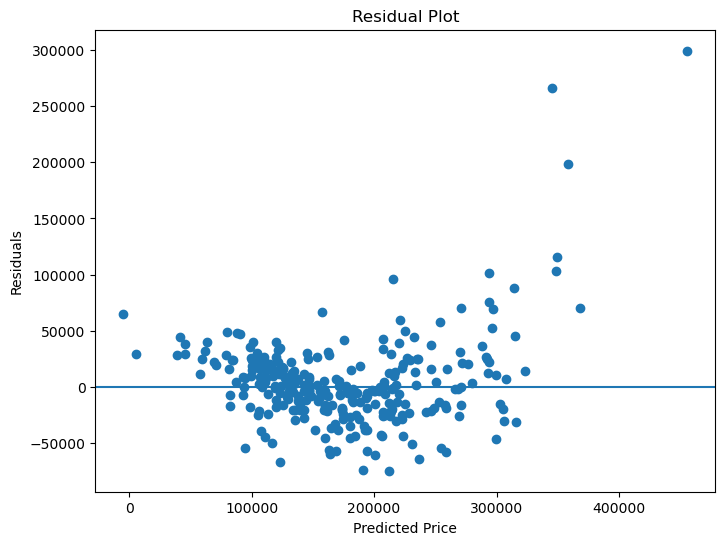

In [20]:
residuals = y_val - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [16]:
test_features = test[features]
test_features = test_features.fillna(X.median())
test_predictions = model.predict(test_features)

In [17]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})
submission.to_csv("submission.csv", index=False)
print("Submission file created successfully!")

Submission file created successfully!


In [18]:
import pickle
pickle.dump(model, open("house_price_model.pkl", "wb"))
print("Model saved!")

Model saved!
